**Global vs Mask / Non-mask**

In [22]:
## Load and prepare paired table
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.dpi": 130,
    "savefig.dpi": 300,
    "font.size": 9,
    "axes.titlesize": 9.5,
    "axes.labelsize": 9,
    "legend.fontsize": 8.5,
    "xtick.labelsize": 8.5,
    "ytick.labelsize": 8.5,
})

CSV_PATH = "../results/all_pixels/combined_results.csv"
df = pd.read_csv(CSV_PATH, low_memory=False)

TIME_COL = "all_time" if "all_time" in df.columns else "bab_time"
print("TIME_COL:", TIME_COL)

def eps_from_vnnlib(v):
    if not isinstance(v, str):
        return np.nan
    m = re.search(r"eps[_=]?([0-9]*\.?[0-9]+)", v)
    return float(m.group(1)) if m else np.nan

def variant_from_vnnlib(v):
    if not isinstance(v, str):
        return None
    s = v.lower()
    if "seg1" in s or "seg2" in s:
        return None
    if "global" in s:
        return "Global"
    if "seg0" in s:
        # Non-mask patterns first (customize if your naming differs)
        if "nomask" in s or "nonmask" in s or "no_mask" in s or "non_mask" in s or "free" in s:
            return "Seg-0 (Non-mask)"
        if "fixmask" in s or "mask" in s:
            return "Seg-0 (Mask)"
        return "Seg-0 (Unknown)"
    return None

df["eps_vnn"] = df["vnnlib"].apply(eps_from_vnnlib)
df["variant"] = df["vnnlib"].apply(variant_from_vnnlib)

keep = ["Global", "Seg-0 (Mask)", "Seg-0 (Non-mask)"]
d = df[df["variant"].isin(keep)].copy()

# Required columns
need_cols = ["image", "k", "eps_vnn", TIME_COL]
for c in need_cols:
    assert c in d.columns, f"Missing required column: {c}"

# Optional columns (for annotations)
if "percent_changed" not in d.columns:
    d["percent_changed"] = np.nan
if "score" not in d.columns:
    d["score"] = np.nan

# Clean numeric
d["k"] = pd.to_numeric(d["k"], errors="coerce")
d["eps_vnn"] = pd.to_numeric(d["eps_vnn"], errors="coerce")
d[TIME_COL] = pd.to_numeric(d[TIME_COL], errors="coerce")
d["percent_changed"] = pd.to_numeric(d["percent_changed"], errors="coerce")
d["score"] = pd.to_numeric(d["score"], errors="coerce")

d = d.dropna(subset=["image", "k", "eps_vnn", TIME_COL])
d = d[(d["k"] > 0) & (d[TIME_COL] > 0)].copy()

pair_keys = ["image", "eps_vnn", "k"]

# Build paired wide table for time, percent_changed, score
time_wide = (
    d.pivot_table(index=pair_keys, columns="variant", values=TIME_COL, aggfunc="mean")
     .reset_index()
)
pct_wide = (
    d.pivot_table(index=pair_keys, columns="variant", values="percent_changed", aggfunc="mean")
     .reset_index()
)
score_wide = (
    d.pivot_table(index=pair_keys, columns="variant", values="score", aggfunc="mean")
     .reset_index()
)

paired = time_wide.merge(pct_wide, on=pair_keys, suffixes=("", "_pct"))
paired = paired.merge(score_wide, on=pair_keys, suffixes=("", "_score"))

# Keep only rows where all three variants exist (so bars are "corresponding")
all3 = paired.dropna(subset=["Global", "Seg-0 (Mask)", "Seg-0 (Non-mask)"]).copy()

print("Paired rows (all 3 variants present):", len(all3))
display(all3.head())
print("Unique eps:", sorted(all3["eps_vnn"].unique())[:10], "...  total:", all3["eps_vnn"].nunique())


TIME_COL: all_time
Paired rows (all 3 variants present): 553


variant,image,eps_vnn,k,Global,Seg-0 (Mask),Seg-0 (Non-mask),Global_pct,Seg-0 (Mask)_pct,Seg-0 (Non-mask)_pct,Global_score,Seg-0 (Mask)_score,Seg-0 (Non-mask)_score
0,n01440764_tench,0.0001,20,11.847602,10.381226,664.844480,0.039860,0.039860,0.039860,NaN,0.475153,0.943832
2,n01440764_tench,0.0001,50,9.122086,731.918861,12.707252,0.099649,0.099649,0.099649,0.943832,0.945320,NaN
4,n01440764_tench,0.0003,40,11.594526,10.528398,704.429736,0.079719,0.079719,0.079719,NaN,0.475153,0.943832
15,n01440764_tench,0.0050,20,8.884467,9.954116,10.450829,0.039860,0.039860,0.039860,0.945320,NaN,0.475153
16,n01440764_tench,0.0050,40,10.381485,8.934021,11.773239,0.079719,0.079719,0.079719,0.943832,0.945320,NaN


Unique eps: [np.float64(0.0001), np.float64(0.0003), np.float64(0.0005), np.float64(0.0007), np.float64(0.001), np.float64(0.005), np.float64(0.01)] ...  total: 7


In [ ]:
import math

def _eps_grid(eps_values, max_cols=4):
    n = len(eps_values)
    cols = min(max_cols, max(1, n))
    rows = math.ceil(n / cols)
    return rows, cols

def _annotate_bar(ax, x, y, txt):
    ax.text(x, y, txt, ha="center", va="bottom", fontsize=7.5, rotation=0)

def _sem(x):
    x = np.asarray(x, dtype=float)
    x = x[~np.isnan(x)]
    if len(x) < 2:
        return np.nan
    return np.std(x, ddof=1) / np.sqrt(len(x))

eps_values = sorted(all3["eps_vnn"].unique())


## Figure 1: Mean runtime

Each subplot corresponds to a fixed ε and shows three bars:
- Global
- Seg-0 (Non-mask)
- Seg-0 (Mask)

Bars show **mean runtime**.
Error bars show **SEM**.
Bar annotations include mean **percent_changed** and (for seg variants) mean **mask score**.


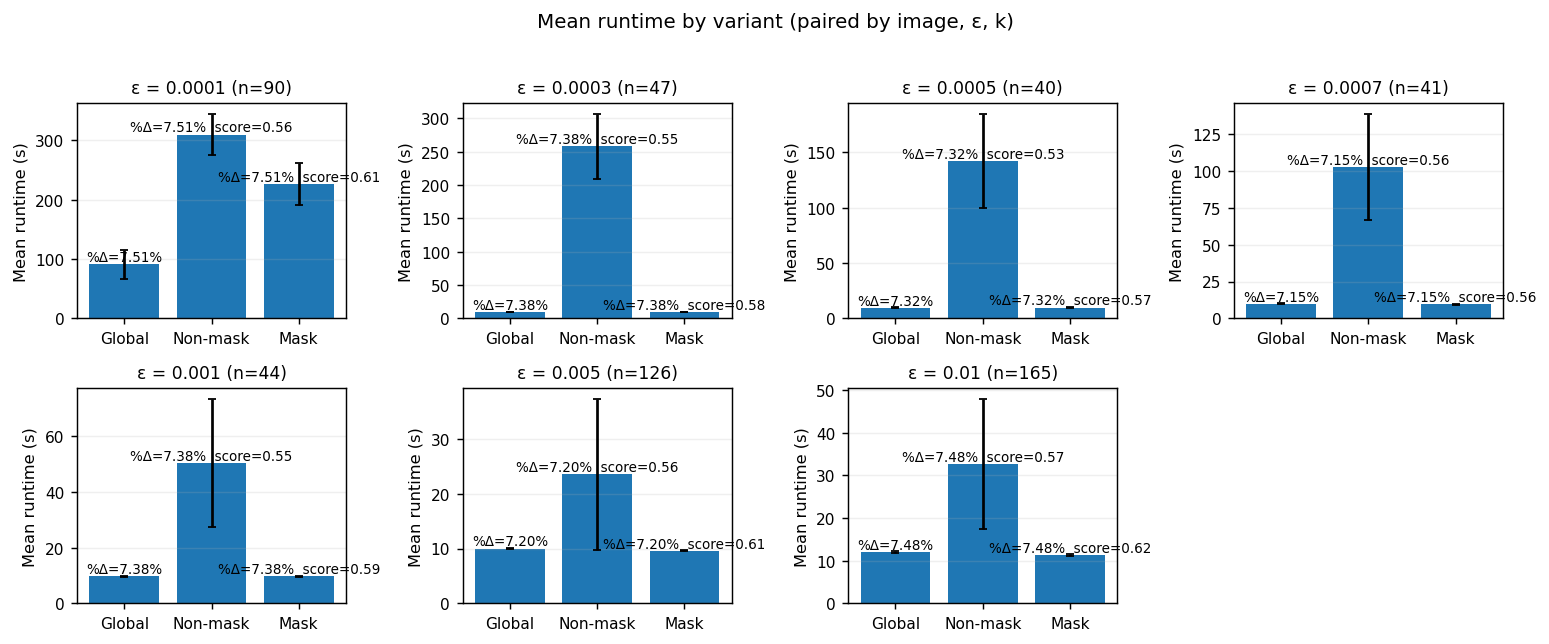

In [ ]:

rows, cols = _eps_grid(eps_values, max_cols=4)
fig, axes = plt.subplots(rows, cols, figsize=(cols*3.0, rows*2.4), squeeze=False)

variants = ["Global", "Seg-0 (Non-mask)", "Seg-0 (Mask)"]
xpos = np.arange(len(variants))

for idx, eps in enumerate(eps_values):
    r, c = divmod(idx, cols)
    ax = axes[r][c]
    sub = all3[all3["eps_vnn"] == eps]

    means = [sub[v].mean() for v in variants]
    sems  = [_sem(sub[v].values) for v in variants]

    ax.bar(xpos, means, yerr=sems, capsize=2)
    ax.set_xticks(xpos)
    ax.set_xticklabels(["Global", "Non-mask", "Mask"], rotation=0)
    ax.set_title(f"ε = {eps:g} (n={len(sub)})")
    ax.set_ylabel("Mean runtime (s)")
    ax.grid(True, axis="y", alpha=0.2)

    # Annotations: percent_changed + score (where available)
    # percent_changed columns are stored in the merged table as the same variant names but from pct_wide;
    # after merge, they still appear as columns named like variants (because we merged different wide tables).
    # We therefore look for columns in paired that come from pct_wide/score_wide by checking duplicates:
    # In our merged "paired", percent_changed columns are NOT suffixed, because pct_wide had same names.
    # To avoid ambiguity, we rely on the _pct and _score suffix columns created by merge suffixes.
    # After merge, pct_wide columns got suffix "_pct" (because time_wide already had those names).
    # score_wide columns got suffix "_score" at final merge.
    for j, v in enumerate(variants):
        pct_col = f"{v}_pct" if f"{v}_pct" in sub.columns else None
        sc_col  = f"{v}_score" if f"{v}_score" in sub.columns else None

        pct_mean = sub[pct_col].mean() if pct_col else np.nan
        sc_mean  = sub[sc_col].mean() if sc_col else np.nan

        label_parts = []
        if not np.isnan(pct_mean):
            label_parts.append(f"%Δ={pct_mean*100:.2f}%")
        if v != "Global" and not np.isnan(sc_mean):
            label_parts.append(f"score={sc_mean:.2f}")

        if label_parts:
            _annotate_bar(ax, j, means[j], "  ".join(label_parts))

# Hide unused subplots
for j in range(len(eps_values), rows*cols):
    r, c = divmod(j, cols)
    axes[r][c].axis("off")

fig.suptitle("Mean runtime by variant (paired by image, ε, k)", y=1.02, fontsize=11)
plt.tight_layout()
plt.show()


In [26]:
import numpy as np
import pandas as pd

# Keep ONLY the exact labels you care about, everything else -> "other"
CANON = ["sat True", "sat False", "unsat False", "timeout False"]

def normalize_result_exact(r):
    s = str(r).strip()
    # make spacing consistent
    s = " ".join(s.split())
    # normalize case to match your list
    s_l = s.lower()
    # map to canonical lowercase labels
    if s_l in [c.lower() for c in CANON]:
        # return exactly as CANON casing
        # (we’ll use lowercase canonical consistently)
        return s_l
    return "other"

d_res = d.copy()
d_res["result_exact"] = d_res["result"].apply(normalize_result_exact)

pair_keys = ["image", "eps_vnn", "k"]
variants = ["Global", "Seg-0 (Non-mask)", "Seg-0 (Mask)"]

# Pivot to wide: one result per (image, eps, k) per variant
res_wide = (
    d_res[d_res["variant"].isin(variants)]
    .pivot_table(
        index=pair_keys,
        columns="variant",
        values="result_exact",
        aggfunc=lambda x: x.iloc[0] if len(x) else np.nan,
    )
    .reset_index()
)

# Keep only fully corresponding triples (all 3 present)
res_all3 = res_wide.dropna(subset=variants).copy()

print("Paired outcome rows (all 3 variants present):", len(res_all3))
display(res_all3.head(10))
print("Unique labels present:", pd.unique(d_res["result_exact"]))

Paired outcome rows (all 3 variants present): 553


variant,image,eps_vnn,k,Global,Seg-0 (Mask),Seg-0 (Non-mask)
0,n01440764_tench,0.0001,20,sat true,sat true,unsat false
2,n01440764_tench,0.0001,50,sat true,unsat false,sat false
4,n01440764_tench,0.0003,40,sat true,sat true,unsat false
15,n01440764_tench,0.0050,20,sat true,sat true,sat true
16,n01440764_tench,0.0050,40,sat true,sat true,sat false
19,n01440764_tench,0.0100,40,sat true,sat true,sat true
20,n01440764_tench,0.0100,50,sat true,sat true,sat false
28,n01443537_goldfish,0.0005,40,sat true,sat true,unsat false
32,n01443537_goldfish,0.0007,50,sat true,sat true,unsat false
36,n01443537_goldfish,0.0050,20,sat true,sat true,sat false


Unique labels present: ['sat true' 'sat false' 'unsat false']


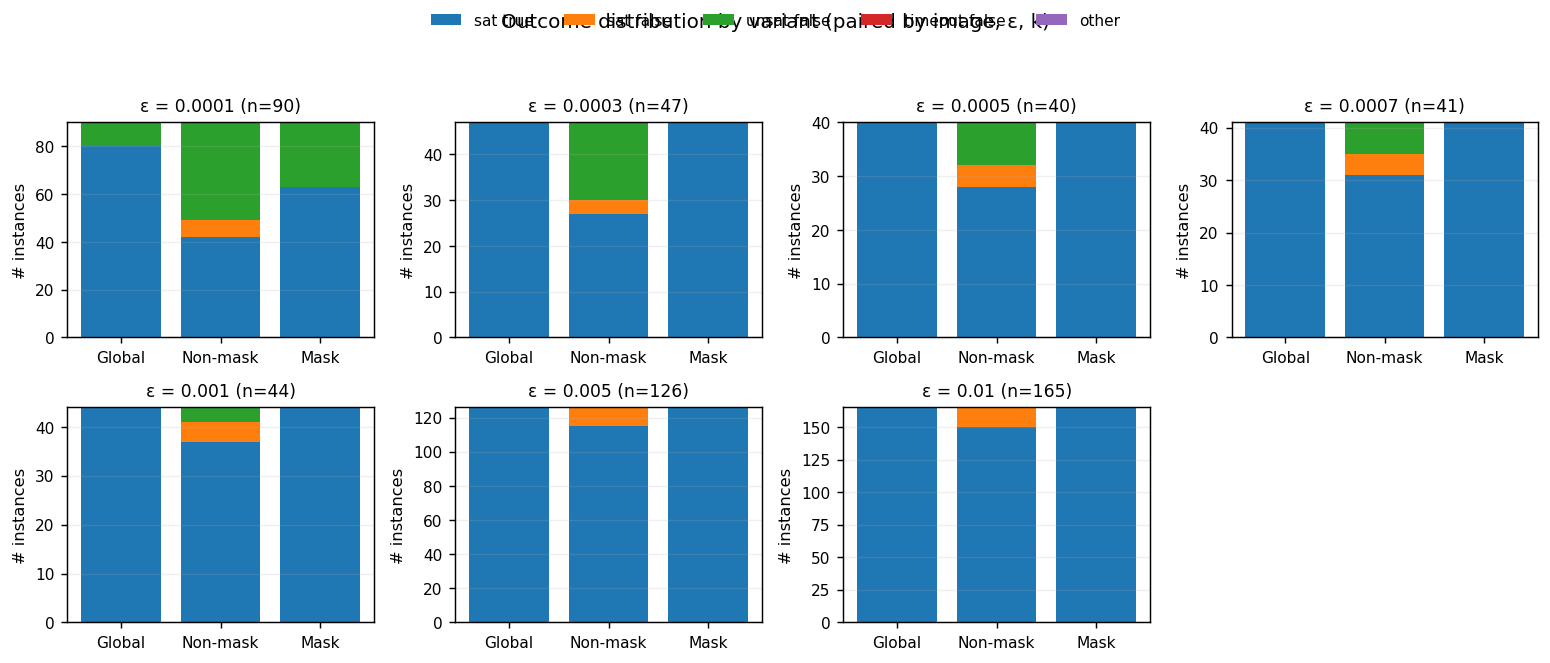

In [27]:
import math
import matplotlib.pyplot as plt
import numpy as np

order = ["sat true", "sat false", "unsat false", "timeout false", "other"]

eps_values = sorted(res_all3["eps_vnn"].unique())
max_cols = 4
cols = min(max_cols, max(1, len(eps_values)))
rows = math.ceil(len(eps_values) / cols)

fig, axes = plt.subplots(rows, cols, figsize=(cols*3.0, rows*2.4), squeeze=False)

for idx, eps in enumerate(eps_values):
    r, c = divmod(idx, cols)
    ax = axes[r][c]
    sub = res_all3[res_all3["eps_vnn"] == eps]

    x = np.arange(len(variants))
    bottom = np.zeros(len(variants), dtype=float)

    for lab in order:
        vals = np.array([(sub[v] == lab).sum() for v in variants], dtype=float)
        ax.bar(x, vals, bottom=bottom, label=lab)
        bottom += vals

    ax.set_xticks(x)
    ax.set_xticklabels(["Global", "Non-mask", "Mask"])
    ax.set_title(f"ε = {eps:g} (n={len(sub)})")
    ax.set_ylabel("# instances")
    ax.grid(True, axis="y", alpha=0.2)

# Hide unused axes
for j in range(len(eps_values), rows*cols):
    r, c = divmod(j, cols)
    axes[r][c].axis("off")

handles, labels = axes[0][0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=len(order), frameon=False)
fig.suptitle("Outcome distribution by variant (paired by image, ε, k)", y=1.05, fontsize=11)

plt.tight_layout()
plt.show()